In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)

[PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem/r2000_a20'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem/big_overview_10_10000p'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem/big_overview_20_10000p'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem/.DS_Store')]

In [3]:
# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2025_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_h_kxylem"


In [4]:
#scenario_name = "r2000_a20"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')

In [5]:
vars_total = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta',  'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation','g_bark']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat','huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0','jackson_root_beta']

In [6]:
df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
# df = df[df['RMSE_MAX'] < 1.1]
# index_to_drop = df[(df['sid'] == 2) | (df['sid'] == 2)].index
# df.drop(index_to_drop, inplace=True)
df_mean = df.groupby(['id'])[vars_total].mean()


In [7]:
def round_sigfig(num, sig_figs):
    """Rounds a number to a specified number of significant figures.

    Args:
        num: The number to round.
        sig_figs: The number of significant figures.

    Returns:
        The rounded number.
    """

    if num == 0:
        return 0
    else:
        return round(num, sig_figs - int(np.floor(np.log10(abs(num)))) - 1)
    

In [8]:
vars_plant

['stem_hydraulic_capacitance',
 'k_xylem_sat',
 'huber_value',
 'leaf_hydraulic_capacitance',
 'psi50_xylem',
 'g0',
 'jackson_root_beta']

In [9]:
vars_sel = ['stem_hydraulic_capacitance', 'k_xylem_sat','huber_value', 'psi50_xylem' ,'g0','jackson_root_beta']
vars_sel_name = [  r"$\Gamma_\mathrm{Stem}$",r"$k_\mathrm{xyl}$",r"Huber", r'$\Psi_{50}$', r"$g_0$",r"$\mathrm{Root}_\beta$"]

In [10]:
vars_sel
units = ["mol m-3 MPa-1", "mol m-1 s-1 MPa-1", "-", "MPa", "mol m-1 s-1", "-"]

stem_hydraulic_capacitance
k_xylem_sat
huber_value
psi50_xylem
g0
jackson_root_beta


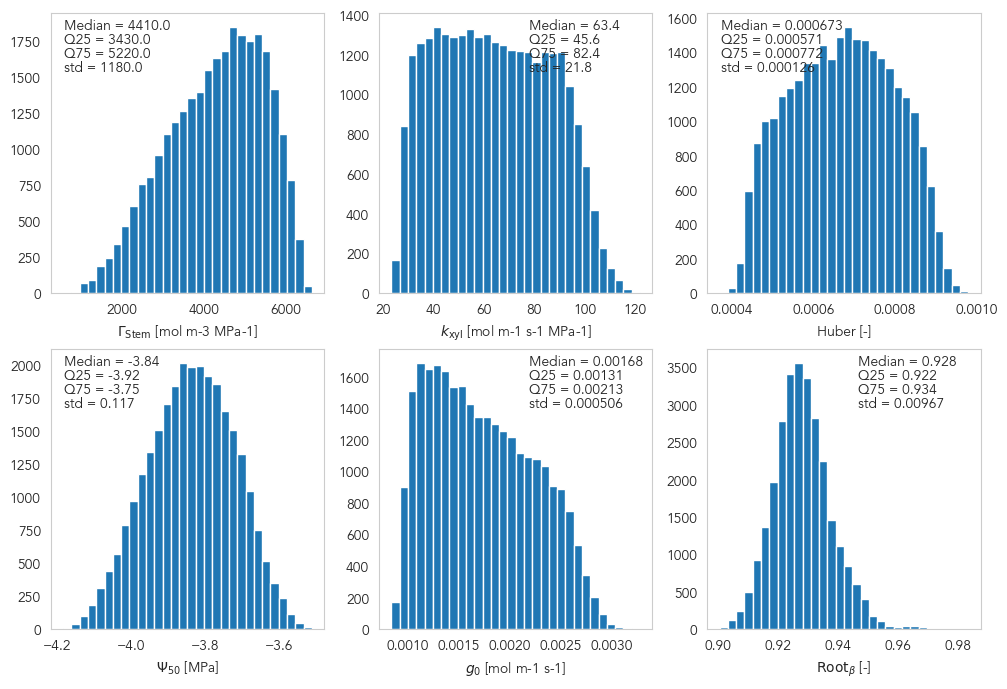

In [21]:
plt.rcParams["font.family"] = "Avenir"
fig = plt.figure(figsize=(12, 8))
i =1 
for var, unit in zip(vars_sel,units):
    ax = fig.add_subplot(2, 3, i)
    ax.hist(df_mean[var], alpha=1.0, bins=30);
    ax.set_xlabel(f"{var} [{unit}]")
    if (i < 5 ) & (i!=2):
        ax.text(0.05,0.94,f"Median = {round_sigfig(df_mean[var].median(),3)}", transform=ax.transAxes);
        ax.text(0.05,0.89,f"Q25 = {round_sigfig(df_mean[var].quantile(q = 0.25),3)}", transform=ax.transAxes);
        ax.text(0.05,0.84,f"Q75 = {round_sigfig(df_mean[var].quantile(q = 0.75),3)}", transform=ax.transAxes);
        ax.text(0.05,0.79,f"std = {round_sigfig(df_mean[var].std(),3)}", transform=ax.transAxes);
    else:
        ax.text(0.55,0.94,f"Median = {round_sigfig(df_mean[var].median(),3)}", transform=ax.transAxes);
        ax.text(0.55,0.89,f"Q25 = {round_sigfig(df_mean[var].quantile(q = 0.25),3)}", transform=ax.transAxes);
        ax.text(0.55,0.84,f"Q75 = {round_sigfig(df_mean[var].quantile(q = 0.75),3)}", transform=ax.transAxes);
        ax.text(0.55,0.79,f"std = {round_sigfig(df_mean[var].std(),3)}", transform=ax.transAxes);

    ax.grid(False)
    ax.set_xlabel(f"{vars_sel_name[i-1]} [{units[i-1]}]")
    i+=1
    print(var)

plt.savefig(f"{post_path}/figure3_selective_variables.png", bbox_inches='tight', dpi = 300)
plt.show()
# plt.close(fig)


In [13]:
df_mean['bins_kapp'] =pd.cut(df_mean[vars_sel[0]], bins = [0,3000,4000,5000,6000,7000])

(array([471., 351., 257., 138.,  54.,  15.,   1.,   0.,   0.]),
 array([6000., 6100., 6200., 6300., 6400., 6500., 6600., 6700., 6800.,
        6900.]),
 <BarContainer object of 9 artists>)

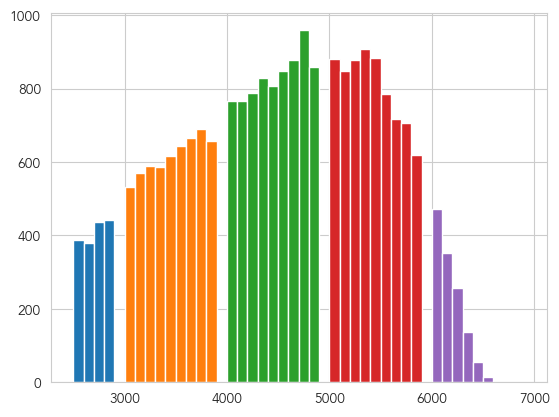

In [14]:
dh = df_mean[df_mean['bins_kapp'] == pd.Interval(left=0, right=3000)]
plt.hist(dh['stem_hydraulic_capacitance'],bins=np.arange(2500,3000,100))
dh = df_mean[df_mean['bins_kapp'] == pd.Interval(left=3000, right=4000)]
plt.hist(dh['stem_hydraulic_capacitance'],bins=np.arange(3000,4000,100))
dh = df_mean[df_mean['bins_kapp'] == pd.Interval(left=4000, right=5000)]
plt.hist(dh['stem_hydraulic_capacitance'],bins=np.arange(4000,5000,100))
dh = df_mean[df_mean['bins_kapp'] == pd.Interval(left=5000, right=6000)]
plt.hist(dh['stem_hydraulic_capacitance'],bins=np.arange(5000,6000,100))
dh = df_mean[df_mean['bins_kapp'] == pd.Interval(left=6000, right=7000)]
plt.hist(dh['stem_hydraulic_capacitance'],bins=np.arange(6000,7000,100))

/Users/pp/anaconda3/envs/PHS-post/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


(array([[         nan,          nan,          nan,          nan,
                  nan,          nan,          nan],
        [852.44267198, 701.2296444 , 518.86008641, 333.58258558,
          92.22333001,   1.66168162,   0.        ],
        [705.64270947, 674.93615469, 554.54213791, 441.7487535 ,
         120.69804208,   2.43220236,   0.        ],
        [436.58028389, 598.71076963, 664.80010418, 604.57090767,
         190.45448626,   4.88344837,   0.        ],
        [130.14763015, 417.63791764, 695.41569542, 860.52836053,
         384.61538462,  11.65501166,   0.        ]]),
 array([0.001 , 0.0014, 0.0018, 0.0022, 0.0026, 0.003 , 0.0034, 0.0038]),
 <a list of 5 BarContainer objects>)

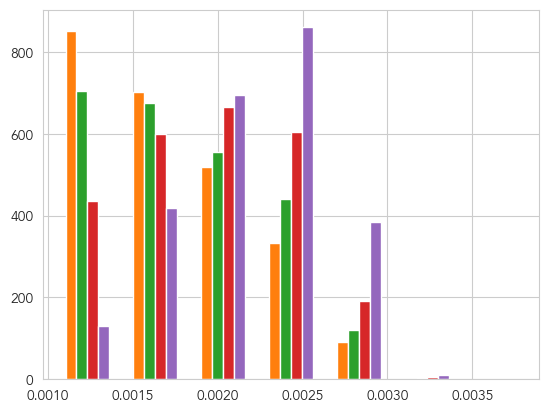

In [15]:
dh1 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=2000, right=3000)]
dh2 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=3000, right=4000)]
dh3 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=4000, right=5000)]
dh4 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=5000, right=6000)]
dh5 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=6000, right=7000)]

plt.hist([dh1['g0'].values,
          dh2['g0'].values,
          dh3['g0'].values,
          dh4['g0'].values,
          dh5['g0'].values],
         bins=np.arange(0.001, 0.004,0.0004
                        ), histtype='bar', density=True)


/Users/pp/anaconda3/envs/PHS-post/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


(array([[          nan,           nan,           nan,           nan,
                   nan,           nan,           nan,           nan,
                   nan],
        [   0.        ,    0.        ,  806.58041846, 1720.17249641,
         2357.45088644, 2649.73646382, 2180.16291327,  285.89682159,
            0.        ],
        [   0.        ,    0.        ,  997.97787558, 2129.1780659 ,
         2734.62590698, 2546.68728441, 1439.27679315,  152.25407399,
            0.        ],
        [   0.        ,    9.05679907, 1463.31996377, 2656.22978393,
         2679.51869582, 2125.76012421, 1015.6553241 ,   50.4593091 ,
            0.        ],
        [   0.        ,   15.54001554, 1965.81196581, 2952.6029526 ,
         2579.64257964, 1849.26184926,  613.83061383,   23.31002331,
            0.        ]]),
 array([0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009,
        0.001 , 0.0011]),
 <a list of 5 BarContainer objects>)

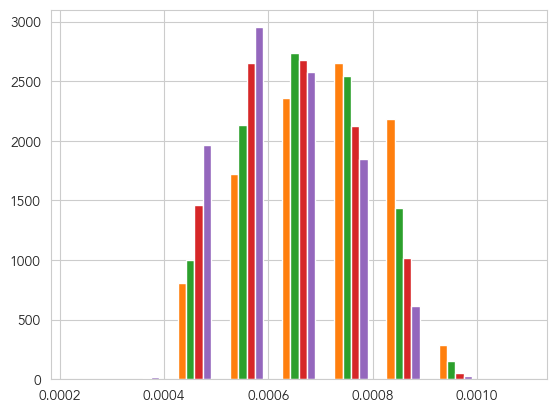

In [16]:
dh1 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=2000, right=3000)]
dh2 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=3000, right=4000)]
dh3 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=4000, right=5000)]
dh4 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=5000, right=6000)]
dh5 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=6000, right=7000)]

plt.hist([dh1['huber_value'].values,
          dh2['huber_value'].values,
          dh3['huber_value'].values,
          dh4['huber_value'].values,
          dh5['huber_value'].values],
         bins=np.arange(0.0002, 0.0012,0.0001), histtype='bar', density=True)

/Users/pp/anaconda3/envs/PHS-post/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


(array([[       nan,        nan,        nan,        nan,        nan,
                nan,        nan],
        [0.14374701, 1.00143747, 2.38300591, 3.10333812, 2.36224245,
         0.89762019, 0.10860885],
        [0.07731652, 0.73272273, 1.81753301, 2.97847032, 2.94635423,
         1.26680147, 0.18080171],
        [0.07633588, 0.56022771, 1.62246086, 3.0663734 , 3.11812654,
         1.37792729, 0.17854832],
        [0.07770008, 0.65268065, 1.98135198, 3.2012432 , 2.78166278,
         1.18104118, 0.12432012]]),
 array([-4.2, -4.1, -4. , -3.9, -3.8, -3.7, -3.6, -3.5]),
 <a list of 5 BarContainer objects>)

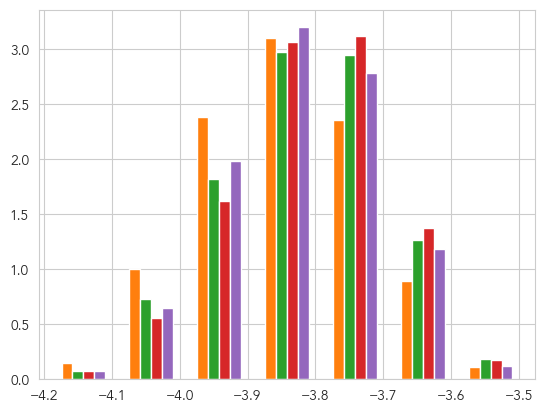

In [17]:
dh1 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=2000, right=3000)]
dh2 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=3000, right=4000)]
dh3 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=4000, right=5000)]
dh4 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=5000, right=6000)]
dh5 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=6000, right=7000)]

plt.hist([dh1['psi50_xylem'].values,
          dh2['psi50_xylem'].values,
          dh3['psi50_xylem'].values,
          dh4['psi50_xylem'].values,
          dh5['psi50_xylem'].values],
         bins=np.arange(-4.2,-3.5, 0.1), histtype='bar', density=True)

/Users/pp/anaconda3/envs/PHS-post/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


(array([[       nan,        nan,        nan,        nan,        nan,
                nan],
        [0.        , 0.00763974, 0.01502249, 0.01506921, 0.01476549,
         0.01416973],
        [0.        , 0.00795747, 0.01572319, 0.01525254, 0.01393646,
         0.01379701],
        [0.        , 0.00668742, 0.01492171, 0.0158838 , 0.01475193,
         0.01442181],
        [0.        , 0.00575705, 0.01519862, 0.01393207, 0.01548647,
         0.01629246]]),
 array([ 5., 20., 35., 50., 65., 80., 95.]),
 <a list of 5 BarContainer objects>)

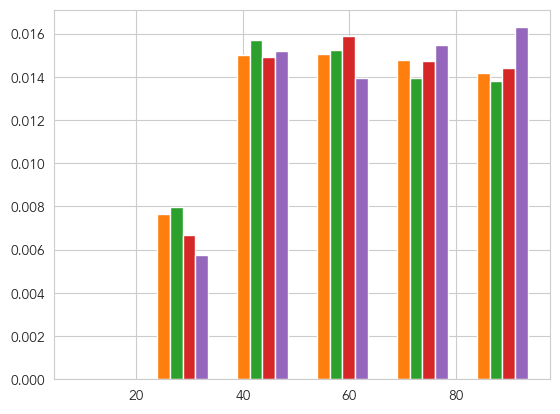

In [18]:
dh1 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=2000, right=3000)]
dh2 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=3000, right=4000)]
dh3 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=4000, right=5000)]
dh4 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=5000, right=6000)]
dh5 = df_mean[df_mean['bins_kapp'] == pd.Interval(left=6000, right=7000)]

plt.hist([dh1['k_xylem_sat'].values,
          dh2['k_xylem_sat'].values,
          dh3['k_xylem_sat'].values,
          dh4['k_xylem_sat'].values,
          dh5['k_xylem_sat'].values],
         bins=np.arange(5,100, 15), histtype='bar', density=True)

ValueError: cannot convert float NaN to integer

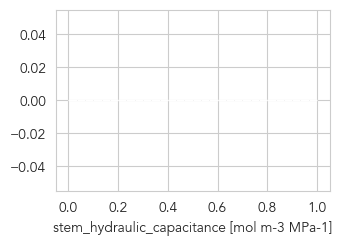

In [19]:
df_mean_1= df[df['sid'] == 4]
fig = plt.figure(figsize=(12, 8))
i = 1 
for var, unit in zip(vars_sel,units):
    ax = fig.add_subplot(3, 3, i)
    ax.hist(df_mean_1[var], alpha=1.0, bins=30);
    ax.set_xlabel(f"{var} [{unit}]")
    if i < 5:
        ax.text(0.05,0.94,f"Median = {round_sigfig(df_mean_1[var].median(),3)}", transform=ax.transAxes);
        ax.text(0.05,0.89,f"Q25 = {round_sigfig(df_mean_1[var].quantile(q = 0.25),3)}", transform=ax.transAxes);
        ax.text(0.05,0.84,f"Q75 = {round_sigfig(df_mean_1[var].quantile(q = 0.75),3)}", transform=ax.transAxes);
    else:
        ax.text(0.6,0.94,f"Median = {round_sigfig(df_mean_1[var].median(),3)}", transform=ax.transAxes);
        ax.text(0.6,0.89,f"Q25 = {round_sigfig(df_mean_1[var].quantile(q = 0.25),3)}", transform=ax.transAxes);
        ax.text(0.6,0.84,f"Q75 = {round_sigfig(df_mean_1[var].quantile(q = 0.75),3)}", transform=ax.transAxes);
    ax.grid(False)
    i+=1
    print(var)

plt.savefig(f"{post_path}/figure3_selective_variables_dead_1.png", bbox_inches='tight', dpi = 300)
plt.show()

In [ ]:
df_mean_1= df[df['sid'] == 1]